# From Quantum Levels to Photonics: Hydrogen Orbitals, Spin, and Light

The hydrogen atom is where quantized energy *levels*, the *spin* of the electron, and the *photons*
of photonics all meet. An electron in level $n$ has energy $E_n=-13.6\,\mathrm{eV}/n^2$; its
wavefunction $\psi_{nlm}=R_{nl}(r)\,Y_l^m(\theta,\phi)$ has a shape we can **render as a surface** (the
familiar s/p/d orbitals); it carries spin $\pm\tfrac12$; and when it drops between levels it emits a
**photon** whose wavelength is the spectral line you see in a discharge tube.

That last step — *level transition $\to$ photon* — is the doorway from quantum mechanics to
photonics, and to this repo's spectroscopy. Engine: `griffiths.quantum` (built on
`sympy.physics.hydrogen`).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math
from griffiths import quantum as q

sp.init_printing(use_latex="mathjax")
print("griffiths.quantum hydrogen tools loaded")

griffiths.quantum hydrogen tools loaded


## §1 Quantum levels: the energy ladder

$E_n=-13.6\,\mathrm{eV}/n^2$ — bound states crowd toward $0$ as $n\to\infty$. The gaps between levels
*are* the photon energies. Below, the ladder with the Lyman ($\to1$) and Balmer ($\to2$) emission
series drawn as downward jumps.

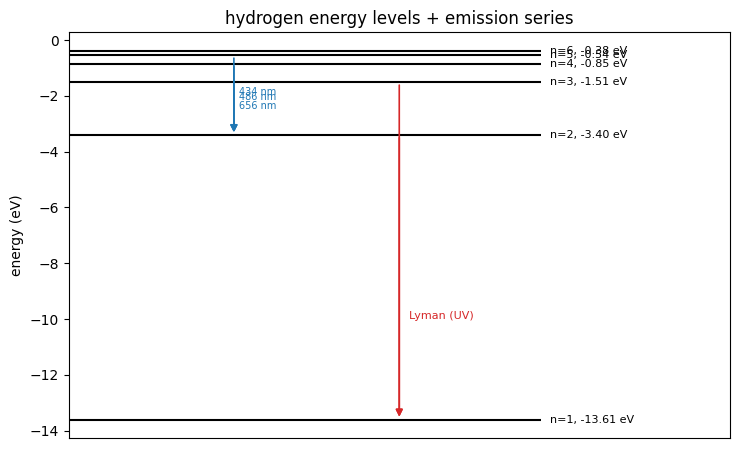

In [2]:
ns = np.arange(1, 7)
E = np.array([q.hydrogen_energy(n) for n in ns])
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for n, e in zip(ns, E):
    ax.hlines(e, 0, 1, color="k", lw=1.5)
    ax.text(1.02, e, f"n={n}, {e:.2f} eV", va="center", fontsize=8)
# Balmer (to n=2, visible) and Lyman (to n=1, UV) transitions
for n_hi in (3, 4, 5):
    lam = q.transition_wavelength(n_hi, 2)
    ax.annotate("", xy=(0.35, E[1]), xytext=(0.35, E[n_hi-1]),
                arrowprops=dict(arrowstyle="-|>", color="C0", lw=1.2))
    ax.text(0.36, (E[1]+E[n_hi-1])/2, f"{lam:.0f} nm", fontsize=7, color="C0")
for n_hi in (2, 3):
    ax.annotate("", xy=(0.7, E[0]), xytext=(0.7, E[n_hi-1]),
                arrowprops=dict(arrowstyle="-|>", color="C3", lw=1.2))
ax.text(0.72, -10, "Lyman (UV)", color="C3", fontsize=8)
ax.set_xlim(0, 1.4); ax.set_ylabel("energy (eV)"); ax.set_xticks([])
ax.set_title("hydrogen energy levels + emission series"); plt.tight_layout(); plt.show()

## §2 The radial wavefunctions

$R_{nl}(r)$ sets how the electron's probability spreads out in radius; the radial probability density
$r^2R_{nl}^2$ peaks near the Bohr radius for the ground state and pushes outward with $n$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

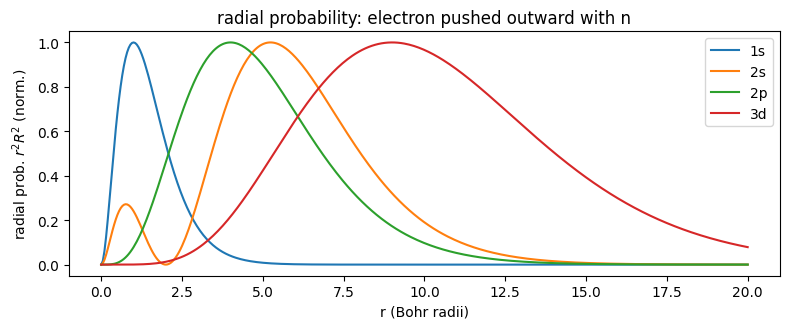

In [3]:
r = sp.Symbol("r", positive=True)
for (n, l) in [(1, 0), (2, 0), (2, 1), (3, 2)]:
    Rnl, _ = q.hydrogen_radial(n, l)
    display(Math(rf"R_{{{n}{l}}}(r) = " + sp.latex(Rnl)))

rg = np.linspace(0, 20, 400)
plt.figure(figsize=(8, 3.4))
for (n, l, lab) in [(1, 0, "1s"), (2, 0, "2s"), (2, 1, "2p"), (3, 2, "3d")]:
    Rnl, rsym = q.hydrogen_radial(n, l)
    f = sp.lambdify(rsym, Rnl, "numpy")
    P = (rg**2) * f(rg)**2
    plt.plot(rg, P/P.max(), label=lab)
plt.xlabel("r (Bohr radii)"); plt.ylabel("radial prob. $r^2R^2$ (norm.)")
plt.title("radial probability: electron pushed outward with n"); plt.legend()
plt.tight_layout(); plt.show()

## §3 Surface rendering: the shape of the orbitals

The angular part $Y_l^m(\theta,\phi)$ gives each orbital its shape. Render it as a surface
$r(\theta,\phi)=|Y|$ — the **s** orbital is a sphere, **p** a dumbbell, **d** the four-lobed clover —
colored by the sign of the wavefunction (the phase that makes bonding work).

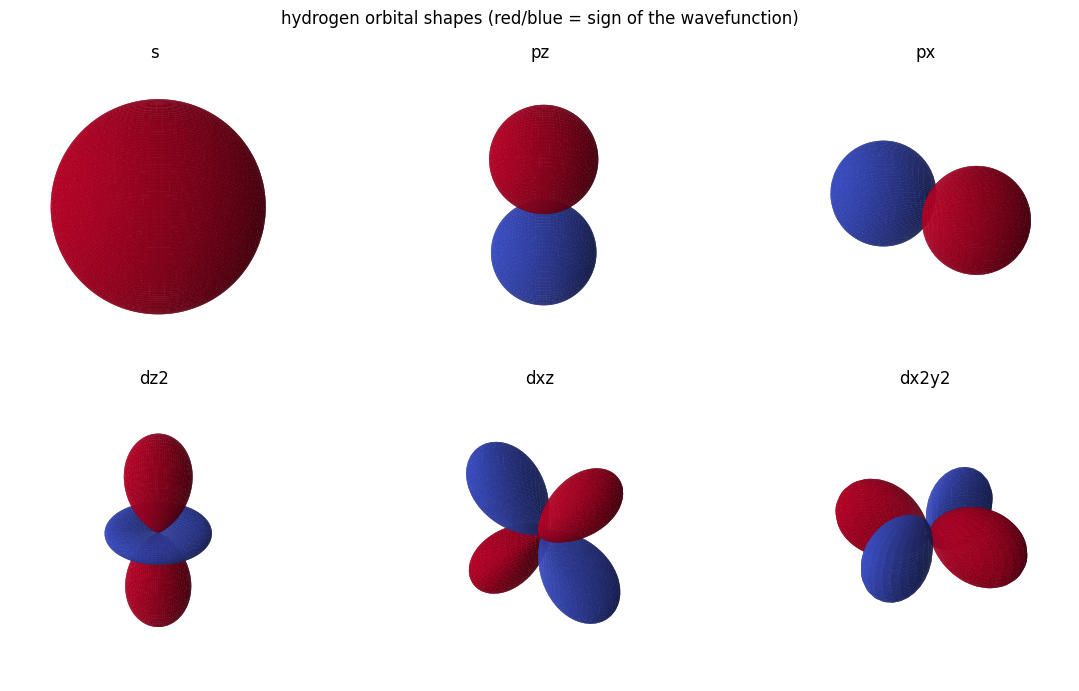

In [4]:
def orbital_surface(ax, name):
    th = np.linspace(0, np.pi, 90); ph = np.linspace(0, 2*np.pi, 90)
    TH, PH = np.meshgrid(th, ph)
    Y = q.real_orbital_angular(name, TH, PH)
    R = np.abs(Y)
    X = R*np.sin(TH)*np.cos(PH); Yc = R*np.sin(TH)*np.sin(PH); Z = R*np.cos(TH)
    cols = plt.cm.coolwarm((np.sign(Y)+1)/2)
    ax.plot_surface(X, Yc, Z, facecolors=cols, rstride=1, cstride=1, antialiased=True, linewidth=0)
    ax.set_title(name); ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
    m = R.max()*0.8
    for s in (ax.set_xlim, ax.set_ylim, ax.set_zlim): s(-m, m)

fig = plt.figure(figsize=(12, 7))
for i, name in enumerate(["s", "pz", "px", "dz2", "dxz", "dx2y2"]):
    ax = fig.add_subplot(2, 3, i+1, projection="3d")
    orbital_surface(ax, name)
fig.suptitle("hydrogen orbital shapes (red/blue = sign of the wavefunction)", y=0.98)
plt.tight_layout(); plt.show()

## §4 Spin orientation: the Bloch sphere

Beyond its orbital, the electron has spin $\tfrac12$ — a two-state system whose orientation is a point
on the **Bloch sphere**. The spinor $|\chi\rangle=(\cos\tfrac\theta2,\ e^{i\phi}\sin\tfrac\theta2)$:
north pole is spin-up, south is spin-down, the equator is an equal up/down superposition (what a
Stern-Gerlach magnet splits).

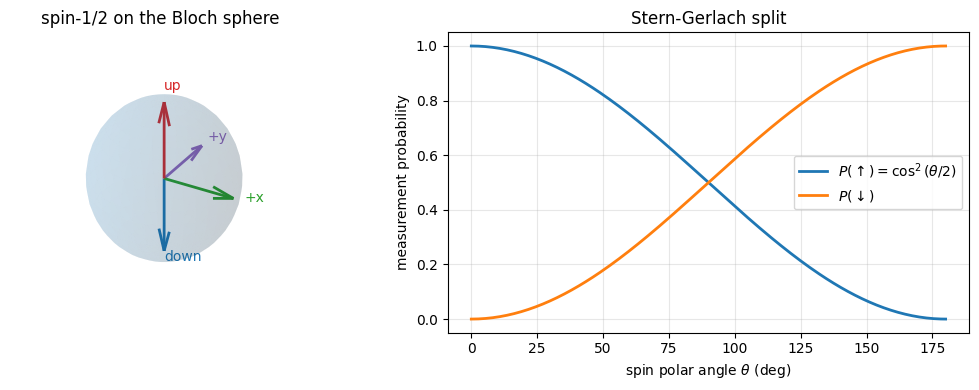

In [5]:
fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax.plot_surface(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                color="C0", alpha=0.12, linewidth=0)
for th, ph, lab, col in [(0, 0, "up", "C3"), (np.pi, 0, "down", "C0"),
                         (np.pi/2, 0, "+x", "C2"), (np.pi/2, np.pi/2, "+y", "C4")]:
    vx, vy, vz = np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)
    ax.quiver(0, 0, 0, vx, vy, vz, color=col, lw=2)
    ax.text(vx*1.15, vy*1.15, vz*1.15, lab, color=col)
ax.set_box_aspect((1, 1, 1)); ax.set_title("spin-1/2 on the Bloch sphere"); ax.set_axis_off()

# Stern-Gerlach: probability of measuring up vs spin angle theta
ax2 = fig.add_subplot(1, 2, 2)
thetas = np.linspace(0, np.pi, 200)
Pup = np.array([np.abs(q.spin_state(t)[0])**2 for t in thetas])
ax2.plot(np.degrees(thetas), Pup, lw=2, label="$P(\\uparrow)=\\cos^2(\\theta/2)$")
ax2.plot(np.degrees(thetas), 1-Pup, lw=2, label="$P(\\downarrow)$")
ax2.set_xlabel("spin polar angle $\\theta$ (deg)"); ax2.set_ylabel("measurement probability")
ax2.set_title("Stern-Gerlach split"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §5 Levels become photons: the spectral fingerprint

A jump $n_{\rm hi}\to n_{\rm lo}$ emits a photon at the Rydberg wavelength, but only if the
electric-dipole **selection rule** $\Delta l=\pm1$ allows it. The **Balmer series** (down to $n=2$)
lands in the visible — the colored lines below are hydrogen's optical fingerprint, the thing a
spectrometer reads.

Balmer series (n -> 2), visible:
  3->2: 656.1 nm
  4->2: 486.0 nm
  5->2: 433.9 nm
  6->2: 410.1 nm
  7->2: 396.9 nm


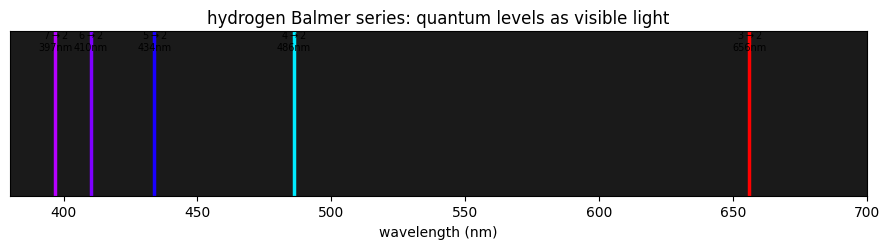


Lyman-alpha (2->1): 121.5 nm (UV)  |  Paschen (4->3): 1874.6 nm (IR)


In [6]:
def wavelength_to_rgb(wl):
    # crude visible-spectrum colour map (380-750 nm)
    if wl < 380 or wl > 750: return (0.4, 0.4, 0.4)
    if wl < 440: r, g, b = -(wl-440)/60, 0, 1
    elif wl < 490: r, g, b = 0, (wl-440)/50, 1
    elif wl < 510: r, g, b = 0, 1, -(wl-510)/20
    elif wl < 580: r, g, b = (wl-510)/70, 1, 0
    elif wl < 645: r, g, b = 1, -(wl-645)/65, 0
    else: r, g, b = 1, 0, 0
    return (max(r,0), max(g,0), max(b,0))

plt.figure(figsize=(9, 2.6))
print("Balmer series (n -> 2), visible:")
for n_hi in range(3, 8):
    lam = q.transition_wavelength(n_hi, 2)
    allowed = q.selection_rule_allowed(1, 0)   # p->s type, dl=1
    plt.axvline(lam, color=wavelength_to_rgb(lam), lw=2.5)
    plt.text(lam, 1.02, f"{n_hi}$\\to$2\n{lam:.0f}nm", ha="center", fontsize=7)
    print(f"  {n_hi}->2: {lam:.1f} nm")
plt.xlim(380, 700); plt.ylim(0, 1.15); plt.yticks([])
plt.xlabel("wavelength (nm)"); plt.title("hydrogen Balmer series: quantum levels as visible light")
plt.gca().set_facecolor("0.1"); plt.tight_layout(); plt.show()
print("\nLyman-alpha (2->1):", round(q.transition_wavelength(2,1),1), "nm (UV)  |  "
      "Paschen (4->3):", round(q.transition_wavelength(4,3),1), "nm (IR)")

## §6 The bridge to the repo

- **Levels $\to$ photons $\to$ spectroscopy.** The Rydberg transitions here are the simplest case of
  the emission/absorption lines a spectrometer measures; the dispersive Fourier transform in this
  repo *stretches* such spectra into time so a fast photodiode can read them (Jalali time-stretch).
  Atomic lines are the calibration rulers.
- **Spherical harmonics, again.** The orbital surfaces are the same $Y_l^m$ / Legendre functions that
  solved the dielectric sphere (Ch. 4) and live one rung from the spherical-Bessel fibre modes — one
  angular basis across electrostatics, photonics, and atoms.
- **Spin = a two-level system.** The Bloch sphere here is identical to the qubit and to the Rabi
  two-level model in `applied_qm_engineering.ipynb`; an optical clock (and the repo's Katori-clock
  notes) is a laser locked to exactly such a level transition.

Engine additions: `griffiths.quantum` gained `hydrogen_energy`, `hydrogen_radial`,
`transition_wavelength`, `selection_rule_allowed`, `real_orbital_angular`, `spin_state` (verified in
`scripts/smoke_hydrogen.py`: E levels, Balmer 656 nm, Lyman 121.5 nm, spin superpositions).